In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from tsp_backend import polar_to_cartesian, plot_tsp_route, simmulated_annealing_tsp, constant_traffic_factor_func, nearest_neighbor_tsp, calculate_route_cost, make_distance_matrix, check_if_in_polygon



In [ ]:
def traffic_factor_no_traffic(cost : float) -> float:
    return constant_traffic_factor_func(1.0, 0.0, cost)

def traffic_factor_with_traffic(cost : float) -> float:
    return constant_traffic_factor_func(10.0, 4.0, cost)

# Circle

In [ ]:
N = 8
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes_circle_N_8 = polar_to_cartesian(R, phi)

In [ ]:
 

optimal_circle_N_8, optimal_cost_circle_N_8 = simmulated_annealing_tsp(
    nodes_circle_N_8, 
    traffic_factor=traffic_factor_no_traffic, 
    start_point_index=0, 
    rejection_threshold=[20,20,20,20], 
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_circle_N_8.pdf')

In [ ]:
plot_tsp_route(nodes_circle_N_8, 
               optimal_circle_N_8, 
               output_path='plots/optimal_route_circle_N_8.pdf', 
               cost=optimal_cost_circle_N_8, 
               want_axis=False)

In [ ]:
 

nearest_neighbor_circle_N_8 = nearest_neighbor_tsp(nodes_circle_N_8, start_point_index=0)

In [ ]:
optimal_cost_nearest_neighbor_circle_N_8 = calculate_route_cost(
    nodes_circle_N_8, 
    nearest_neighbor_circle_N_8, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_circle_N_8),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_circle_N_8, 
               nearest_neighbor_circle_N_8, 
               output_path='plots/nearest_neighbor_circle_N_8.pdf', 
               cost=optimal_cost_nearest_neighbor_circle_N_8,
               want_axis=False)

# Large Circle


In [ ]:
N = 100
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes_circle_N_100 = polar_to_cartesian(R, phi)

In [ ]:
 

optimal_circle_N_100, optimal_cost_circle_N_100 = simmulated_annealing_tsp(
    nodes_circle_N_100, 
    traffic_factor=traffic_factor_no_traffic, 
    start_point_index=0, 
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_circle_N_100.pdf')

In [ ]:
plot_tsp_route(nodes_circle_N_100, 
               optimal_circle_N_100, 
               output_path='plots/optimal_route_circle_N_100.pdf', 
               cost=optimal_cost_circle_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=False)

In [ ]:
 

nearest_neighbor_circle_N_100 = nearest_neighbor_tsp(nodes_circle_N_100, start_point_index=0)

In [ ]:
optimal_cost_nearest_neighbor_circle_N_100 = calculate_route_cost(
    nodes_circle_N_100, 
    nearest_neighbor_circle_N_100, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_circle_N_100),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_circle_N_100, 
               nearest_neighbor_circle_N_100, 
               output_path='plots/nearest_neighbor_circle_N_100.pdf',
               cost=optimal_cost_nearest_neighbor_circle_N_100,
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=False)

# Two seperated squares of equal lattice nodes

In [ ]:
N = 10

x_coordinates_1 = np.linspace(-1.1, -0.1, N)
y_coordinates_1 = np.linspace(0.1 , 1.1, N)

X, Y = np.meshgrid(x_coordinates_1, y_coordinates_1)
coordinates_1 = np.column_stack([X.flatten(), Y.flatten()])

x_coordinates_2 = np.linspace(0.1, 1.1, N)
y_coordinates_2 = np.linspace(-1.1 , -0.1, N)

X, Y = np.meshgrid(x_coordinates_2, y_coordinates_2)
coordinates_2 = np.column_stack([X.flatten(), Y.flatten()])

nodes_two_squares = np.append(coordinates_1, coordinates_2, axis=0)

In [ ]:
 

optimal_two_square_N_10, optimal_two_square_cost_N_10 = simmulated_annealing_tsp(nodes_two_squares, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_two_squares_N_10.pdf')

In [ ]:
plot_tsp_route(nodes_two_squares, 
               optimal_two_square_N_10, 
               output_path='plots/optimal_route_two_square_N_10.pdf', 
               cost=optimal_two_square_cost_N_10, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

In [ ]:
 

nearest_neighbor_two_square_N_10 = nearest_neighbor_tsp(nodes_two_squares, start_point_index=0)

In [ ]:
optimal_cost_nearest_neighbor_two_square_N_10 = calculate_route_cost(
    nodes_two_squares, 
    nearest_neighbor_two_square_N_10, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_two_squares),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_two_squares, 
               nearest_neighbor_two_square_N_10,
               output_path='plots/nearest_neighbor_two_square_N_10.pdf',
               cost=optimal_cost_nearest_neighbor_two_square_N_10,
               arrow_width=0.008, 
               node_dot_size=10,
               want_axis=True)


# Random points in a unit square

In [ ]:
N = 100
x = np.random.rand(N)
y = np.random.rand(N)
nodes_random_N_100 = np.column_stack([x, y])

In [ ]:
 

optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100.pdf')

In [ ]:
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100, 
               output_path='plots/optimal_route_random_square_N_100.pdf', 
               cost=optimal_random_square_cost_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

In [ ]:
 

nearest_neighbor_random_square_N_100 = nearest_neighbor_tsp(nodes_random_N_100, start_point_index=0)

In [ ]:
optimal_cost_nearest_neighbor_random_square_N_100 = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_random_N_100, 
               nearest_neighbor_random_square_N_100,
               output_path='plots/nearest_neighbor_random_square_N_100.pdf',
               cost=optimal_cost_nearest_neighbor_random_square_N_100,
               arrow_width=0.008,
               node_dot_size=10,
               want_axis=True)

In [ ]:
optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100, 
               output_path='plots/optimal_route_random_square_N_100_2.pdf', 
               cost=optimal_random_square_cost_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

nearest_neighbor_random_square_N_100 = nearest_neighbor_tsp(nodes_random_N_100, start_point_index=0)
optimal_cost_nearest_neighbor_random_square_N_100 = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_random_N_100, 
               nearest_neighbor_random_square_N_100,
               output_path='plots/nearest_neighbor_random_square_N_100_2.pdf',
               arrow_width=0.008,
               node_dot_size=10,
               want_axis=True)

In [ ]:
traffic_polygon = np.array([[0.2, 0.8], [0.8, 0.8], [0.8, 0.2], [0.2, 0.2]])

# With Traffic
### ambigious start point

In [ ]:
 

optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_with_traffic, 
                                                                                  traffic_start_time=4,
                                                                                  traffic_polygon=traffic_polygon,
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100_with_traffic.pdf')

In [ ]:
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100, 
               traffic_polygon=traffic_polygon,
               output_path='plots/optimal_route_random_square_N_100_with_traffic.pdf', 
               cost=optimal_random_square_cost_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

In [ ]:
random_nodes_in_traffic_polygon = np.array([i for i in range(N) if check_if_in_polygon(nodes_random_N_100[i], traffic_polygon)])
random_nodes_outside_traffic_polygon = np.array([i for i in range(N) if not check_if_in_polygon(nodes_random_N_100[i], traffic_polygon)])

optimal_cost_nearest_neighbor_random_square_N_100_traffic = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    random_nodes_in_traffic_polygon, 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
print(f'Optimal cost nearest neighbor random square N 100 with traffic: {optimal_cost_nearest_neighbor_random_square_N_100_traffic}')

### Start point outside of traffic

In [ ]:
# fix the start point to the first index of a node outside of the traffic polygon

start_index = random_nodes_outside_traffic_polygon[0]
# simulate annealing with fixed start point outside of traffic polygon
optimal_random_square_N_100_fixed_start, optimal_random_square_cost_N_100_fixed_start = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=4,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic.pdf')

plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

# nearest neighbor with fixed start point outside of traffic polygon
nearest_neighbor_random_square_N_100_fixed_start = nearest_neighbor_tsp(
    nodes_random_N_100, 
    start_point_index=start_index
)
optimal_cost_nearest_neighbor_random_square_N_100_fixed_start = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100_fixed_start, 
    random_nodes_in_traffic_polygon, 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
# plot the route of the nearest neighbor with fixed start point outside of traffic polygon
plot_tsp_route(nodes_random_N_100, 
               nearest_neighbor_random_square_N_100_fixed_start,
               traffic_polygon=traffic_polygon,
               output_path='plots/nearest_neighbor_random_square_N_100_fixed_start_outside_with_traffic.pdf',
               cost=optimal_cost_nearest_neighbor_random_square_N_100_fixed_start,
               arrow_width=0.008,
               node_dot_size=10,
               want_axis=True)
print(f'Optimal cost nearest neighbor random square N 100 with fixed start: {optimal_cost_nearest_neighbor_random_square_N_100_fixed_start}')

### Fixed start point inside of traffic area

In [ ]:
# start point fixed inside of the traffic polygon
start_index_inside = random_nodes_in_traffic_polygon[0]
optimal_random_square_N_100_fixed_start_inside, optimal_random_square_cost_N_100_fixed_start_inside = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=4,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_inside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_inside_with_traffic.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_inside, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_inside_with_traffic.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_inside,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

nearest_neighbor_random_square_N_100_fixed_start_inside = nearest_neighbor_tsp(
    nodes_random_N_100, 
    start_point_index=start_index_inside
)
optimal_cost_nearest_neighbor_random_square_N_100_fixed_start_inside = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100_fixed_start_inside,
    random_nodes_in_traffic_polygon,
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
plot_tsp_route(nodes_random_N_100,
                nearest_neighbor_random_square_N_100_fixed_start_inside,
                traffic_polygon=traffic_polygon,
                output_path='plots/nearest_neighbor_random_square_N_100_fixed_start_inside_with_traffic.pdf',
                cost=optimal_cost_nearest_neighbor_random_square_N_100_fixed_start_inside,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)
print(f'Optimal cost nearest neighbor random square N 100 with fixed start inside: {optimal_cost_nearest_neighbor_random_square_N_100_fixed_start_inside}')

In [ ]:
# simulated annealing with fixed start point ouside of traffic polygon for three different start times
start_index_outside = random_nodes_outside_traffic_polygon[0]

# instand start
optimal_random_square_N_100_fixed_start_outside_start_0, optimal_random_square_cost_N_100_fixed_start_outside_start_0 = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=0,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_outside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic_start_time_0.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_outside_start_0, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic_start_time_0.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_outside_start_0,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

# start time 4
optimal_random_square_N_100_fixed_start_outside_start_4, optimal_random_square_cost_N_100_fixed_start_outside_start_4 = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=4,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_outside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic_start_time_4.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_outside_start_4, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic_start_time_4.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_outside_start_4,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)
    
# start time 8
optimal_random_square_N_100_fixed_start_outside_start_8, optimal_random_square_cost_N_100_fixed_start_outside_start_8 = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=8,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_outside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic_start_time_8.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_outside_start_8, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic_start_time_8.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_outside_start_8,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

# Altstadt Kneipen


In [ ]:
# read distance matrix for Altstadt Kneipen
altstadt_distance_df = pd.read_csv('Distance_matrix_Altstadt_Kneipen(Tabelle1).csv', delimiter=';')
altstadt_distance_matrix = altstadt_distance_df.to_numpy()[:, 1:].astype(float)  # convert to numpy array and skip the first column which contains the names of the bars

altstadt_cost_matrix = altstadt_distance_matrix / (3.0 / 3.6) # assuming 3 km/h walking speed, so cost is distance in km divided by 5 km/h to get time in hours

In [ ]:
alcohol_effect_start = 60 * 10  # we assume 10 minutes till the effect starts

def drunk_traffic_factor(cost: float) -> float:
    # linearly increasing traffic factor, 
    # assuming half the walking velocity for every promille of alcohol in the blood, starting with a factor of 1.0 at 0 promille and increasing by 1.0 for every additional promille
    return constant_traffic_factor_func(1.0 + 0.005 * (cost - alcohol_effect_start), alcohol_effect_start, cost)


Temperature: 0.1, Current Cost: 2208939.3997114385
Current route: [ 1  5  6  2 12  0  3  7  9 13 11 10  4  8]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 6576.676668672003
Current route: [ 5  4  7 11  9 10 13  0 12  2  8  3  6  1]
num consec rejections: 29, num iter: 117
Temperature: 0.01, Current Cost: 3541.9248000000007
Current route: [ 4  5  8  9 10  7 11  2 12  0 13  1  6  3]
num consec rejections: 200, num iter: 1644
Reached maximum number of iterations for temperature 0.01. :(
Temperature: 0.001, Current Cost: 3541.9248000000007
Current route: [ 4  5  8  9 10  7 11  0 13  2 12  1  6  3]
num consec rejections: 5, num iter: 100002
Reached maximum number of iterations for temperature 0.001. :(


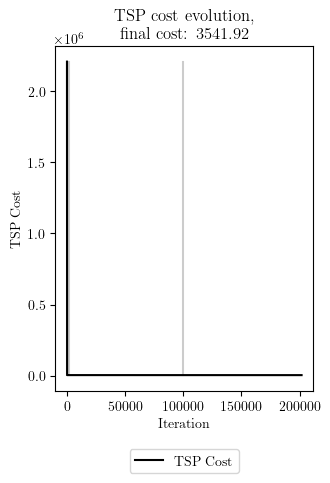

Optimal route 0 (cost: 3541.92 seconds) with drunk traffic factor:
Babel
Moby's
Stadthüsje
Bla
Namenlos
Stachel
Musiktruhe
Nyx
Quiet Man
Pawlow
Wache
John Barleycorn
Pinte
Tresor


In [6]:

# 14 bars in the oldtown nodes
nodes_bars = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [0.5, 0.5], [0.2, 0.8], [0.8, 0.2], [0.3, 0.3], [0.7, 0.7], [0.4, 0.6], [0.6, 0.4], [0.1, 0.9], [0.9, 0.1], [0.5, 0.75]])

routes = []
route_costs = []

for i in range(1): #30):
    drunk_optimal_route, drunk_route_cost = simmulated_annealing_tsp(nodes_bars, 
                            pre_determined_distance_matrix=altstadt_cost_matrix,
                            traffic_factor=drunk_traffic_factor, 
                            traffic_start_time=alcohol_effect_start, 
                            traffic_polygon=np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 1.0], [1.0, 0.0]]),
                            plot_cost=True, 
                            plot_cost_out_path=f'bar_plots/convergence_bars_with_drunk_traffic_{i}.pdf')

    routes.append(drunk_optimal_route)
    route_costs.append(drunk_route_cost)

minimal_cost_index = np.argmin(route_costs)
drunk_optimal_route = routes[minimal_cost_index]

#print("Optimal route with drunk traffic factor:", altstadt_distance_df[0, drunk_optimal_route])
print(f"Optimal route {minimal_cost_index} (cost: {route_costs[minimal_cost_index]:.2f} seconds) with drunk traffic factor:")
for drunk_node in drunk_optimal_route:
    print(f"{altstadt_distance_df.columns[drunk_node + 1]}")


Temperature: 0.1, Current Cost: 5677.200000000001
Current route: [ 4  6  1  0  8  9  3 10  2  5 12 13  7 11]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 2648.4000000000005
Current route: [ 4  5  6 11  7  8  9 10 13  0 12  2  1  3]
num consec rejections: 28, num iter: 91
Temperature: 0.01, Current Cost: 2588.4
Current route: [ 4  3  1  2  0 12 13 10  9  8  7 11  6  5]
num consec rejections: 209, num iter: 25179
Reached maximum number of iterations for temperature 0.01. :(
Temperature: 0.001, Current Cost: 2588.4
Current route: [ 4  3  1  2  0 12 13 10  9  8  7 11  6  5]
num consec rejections: 12, num iter: 100012
Reached maximum number of iterations for temperature 0.001. :(


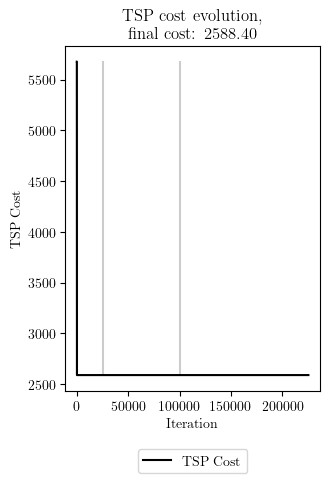

Optimal route with no traffic factor: Index(['Babel', 'Moby's', 'Pinte', 'Musiktruhe', 'Stachel', 'Stadthüsje',
       'Bla', 'Namenlos', 'Wache', 'Quiet Man', 'Nyx', 'Pawlow',
       'John Barleycorn', 'Tresor'],
      dtype='object')


In [12]:
drunk_optimal_route, drunk_route_cost = simmulated_annealing_tsp(nodes_bars, 
                            pre_determined_distance_matrix=altstadt_cost_matrix,
                            traffic_factor=traffic_factor_no_traffic, 
                            start_point_index=4,
                            plot_cost=True, 
                            plot_cost_out_path=f'bar_plots/convergence_bars_sober.pdf')

print("Optimal route with no traffic factor:", altstadt_distance_df.columns[drunk_optimal_route + 1])